In [2]:
%load_ext autoreload
%autoreload 2
from WVS_dataloader import WVSDataLoader

In [3]:
significant_changes_path = '/home/tchakrab/gb-scratch/wvs/data/significant_changes'

loader = WVSDataLoader(
    file_path='/home/tchakrab/gb-scratch/wvs/data/WVS_Time_Series_1981-2022_csv_v5_0.csv',
    cache_path='/home/tchakrab/gb-scratch/wvs/data/averages_cached.csv',

)

Loading cached averages...


In [4]:
prefixes = ['B', 'C', 'D', 'E', 'F', 'G']
for p in prefixes:
    print(f"Processing questions with prefix {p}...")
    results = loader.get_significant_changes(
        wave1=6,
        wave2=7,
        question_prefix=p,
        tests=['welch', 'ks', 'wasserstein'],
        save_dir=significant_changes_path
    )

Processing questions with prefix B...
Loaded existing results for wave6_to_wave7 from /home/tchakrab/gb-scratch/wvs/data/significant_changes
Processing questions with prefix C...
Loaded existing results for wave6_to_wave7 from /home/tchakrab/gb-scratch/wvs/data/significant_changes
Processing questions with prefix D...
Loaded existing results for wave6_to_wave7 from /home/tchakrab/gb-scratch/wvs/data/significant_changes
Processing questions with prefix E...
Loaded existing results for wave6_to_wave7 from /home/tchakrab/gb-scratch/wvs/data/significant_changes
Processing questions with prefix F...
Loaded existing results for wave6_to_wave7 from /home/tchakrab/gb-scratch/wvs/data/significant_changes
Processing questions with prefix G...
Loaded existing results for wave6_to_wave7 from /home/tchakrab/gb-scratch/wvs/data/significant_changes


In [5]:
import pandas as pd
question_prefix = 'A'
wave_a = '5'
wave_b = '6'
wave_c = '7'
wave_a_to_b = pd.read_csv(f'{significant_changes_path}/ks/{question_prefix}_wave{wave_a}_to_wave{wave_b}.csv')
wave_b_to_c = pd.read_csv(f'{significant_changes_path}/ks/{question_prefix}_wave{wave_b}_to_wave{wave_c}.csv')

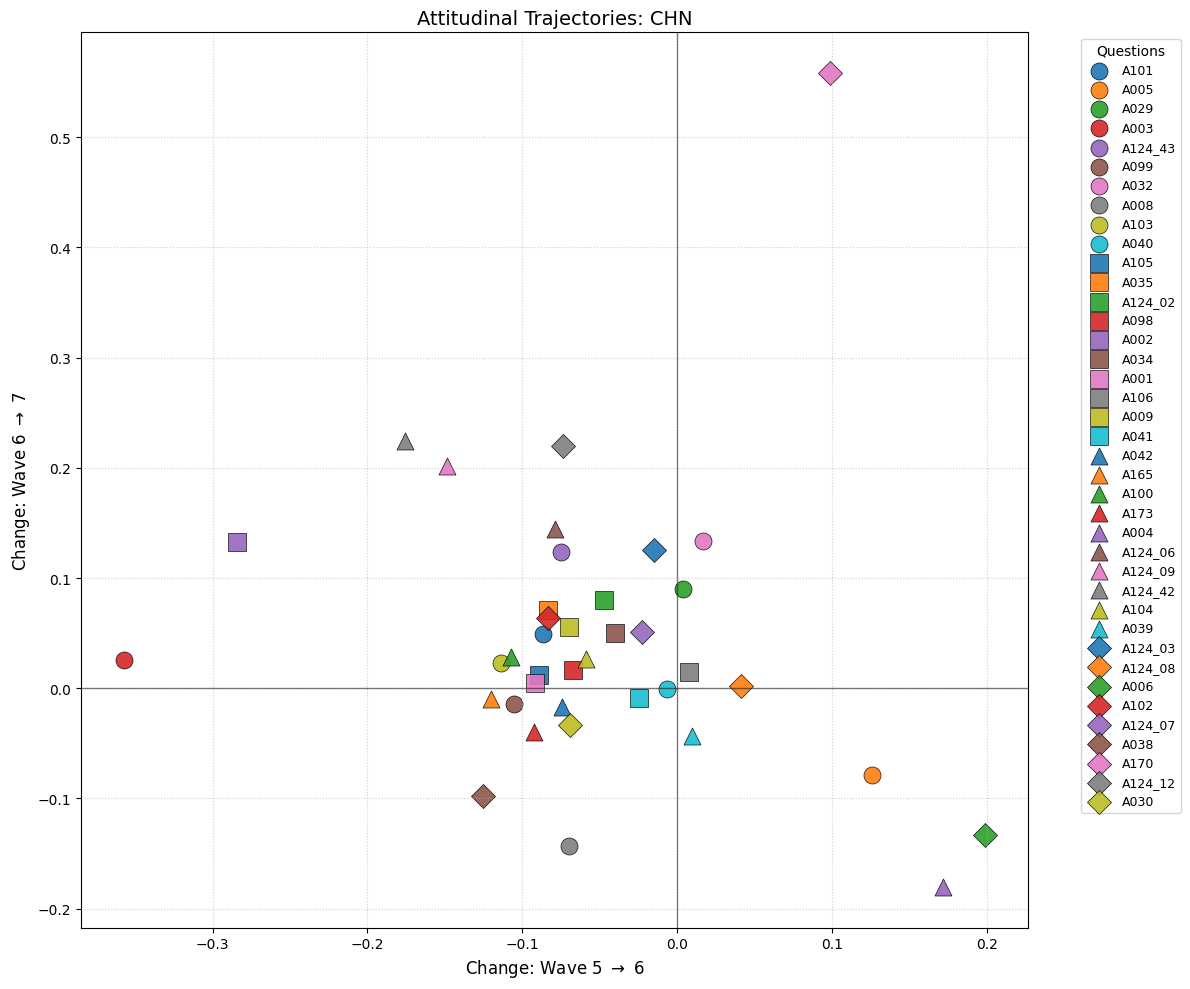

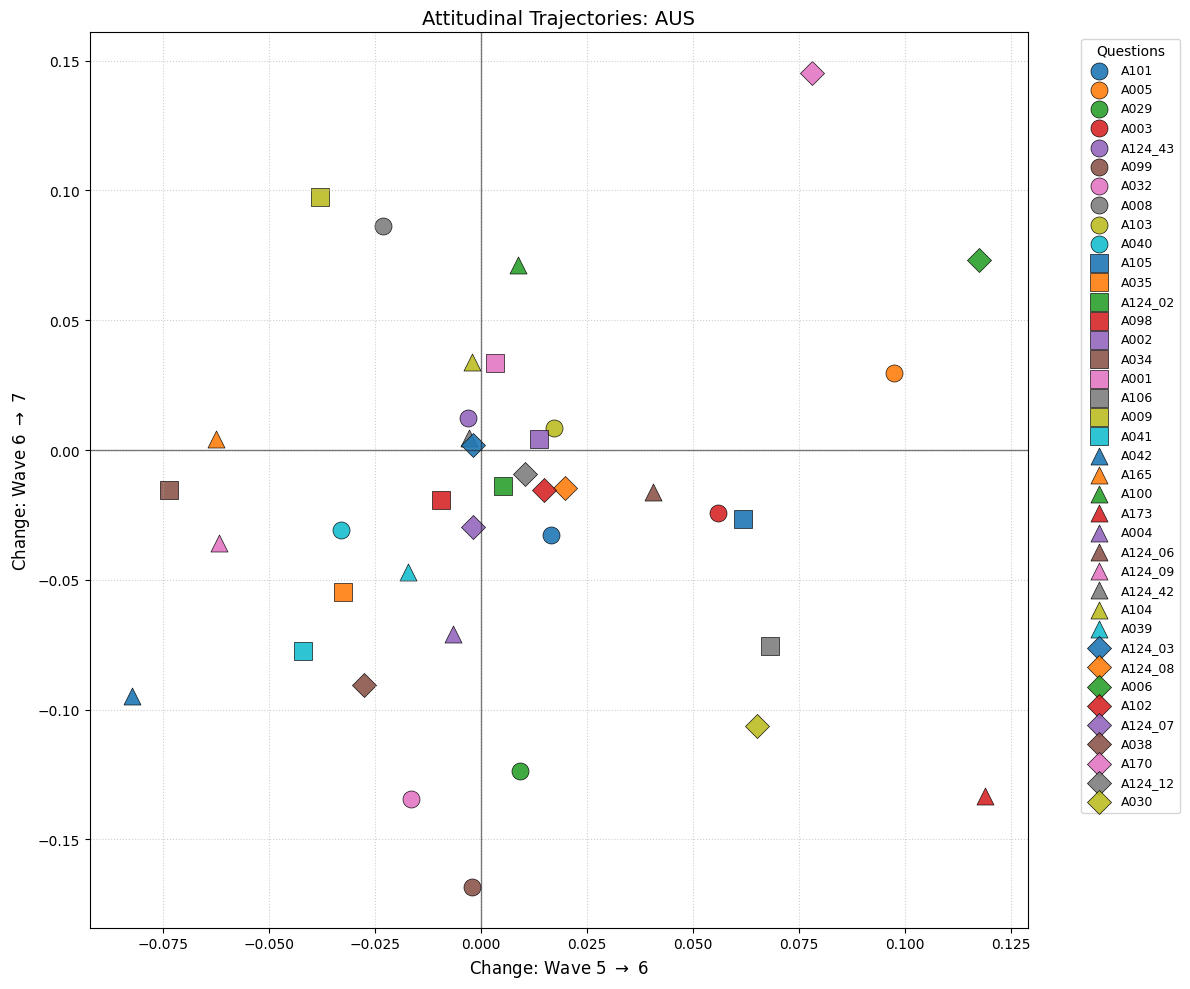

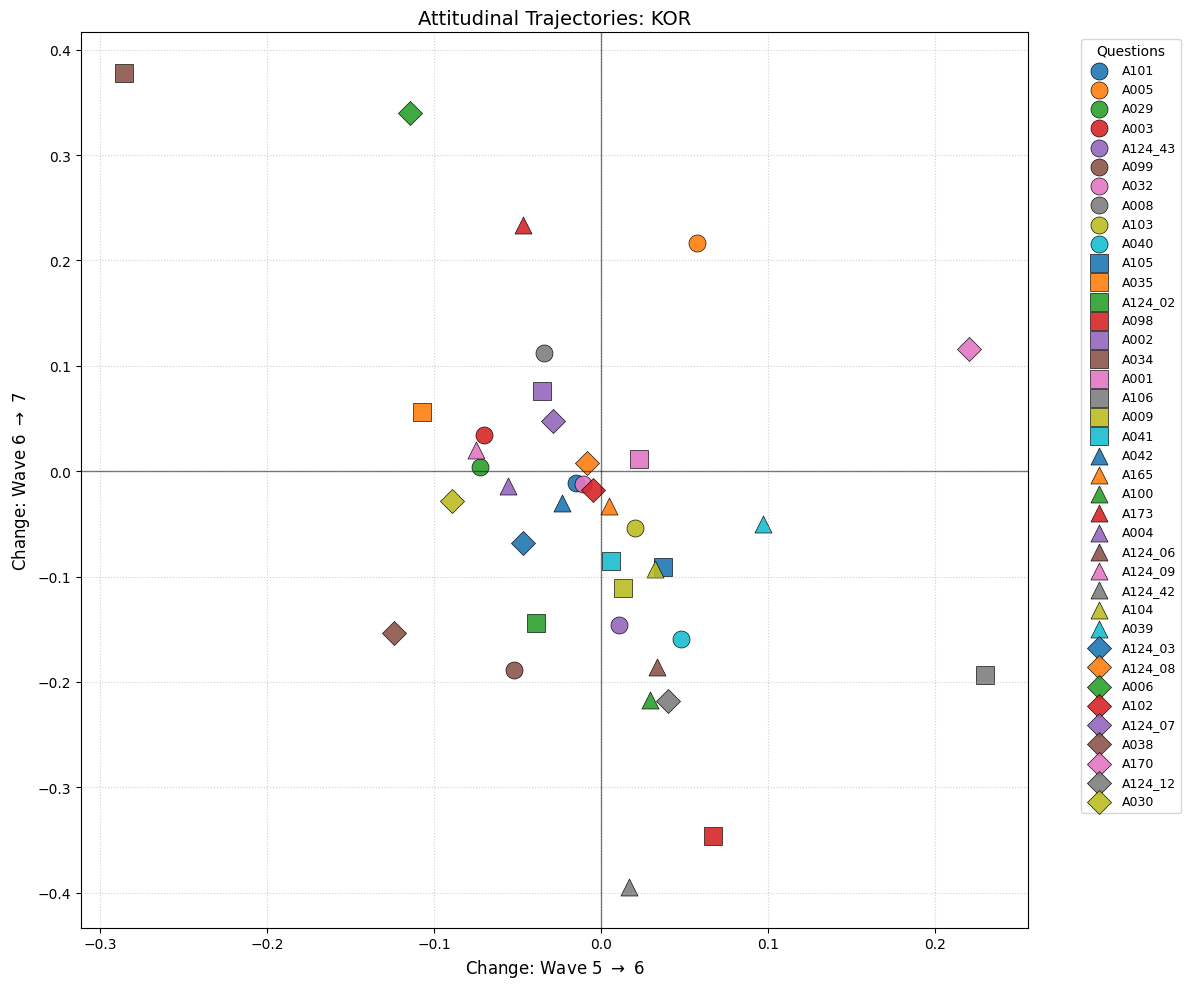

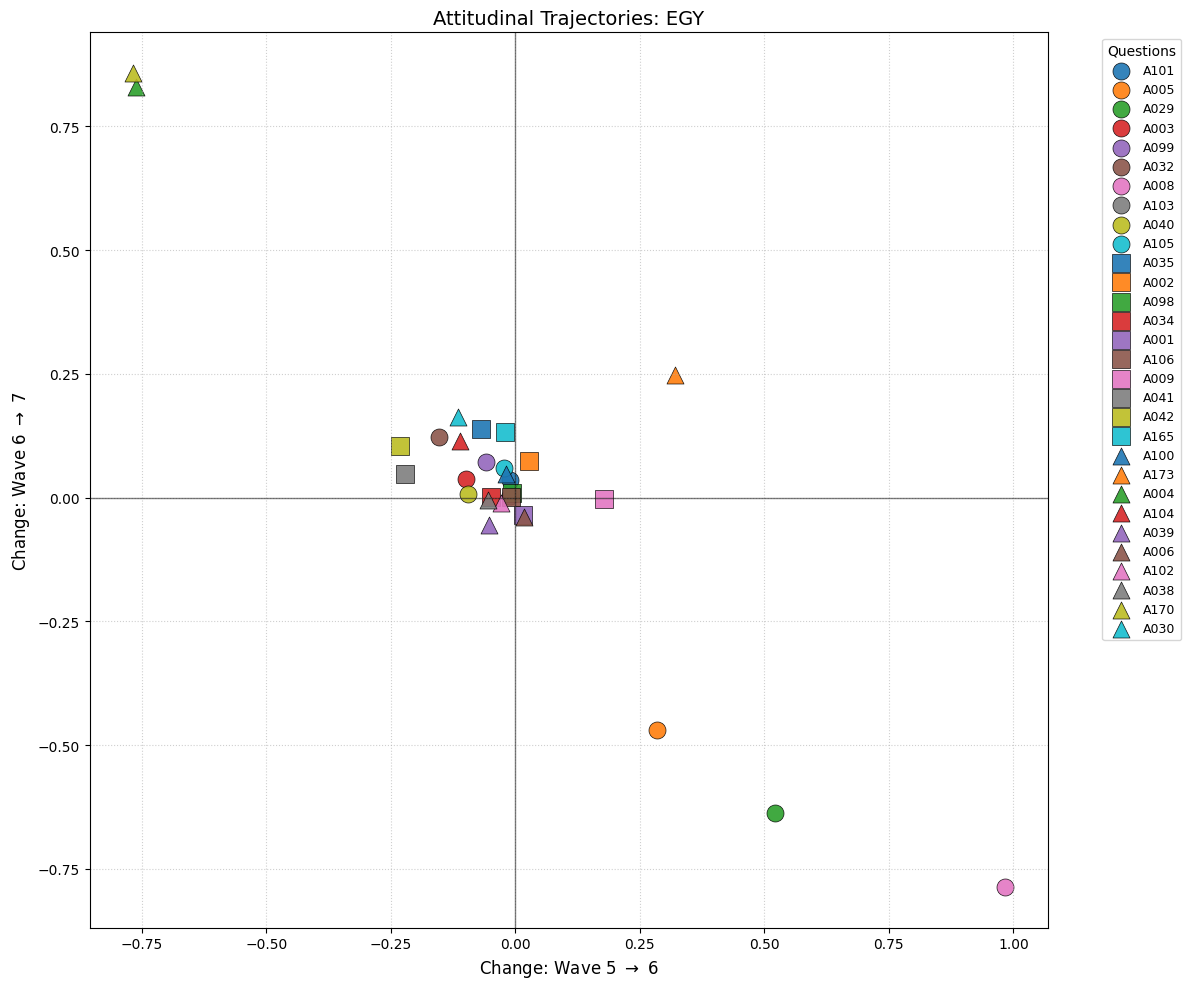

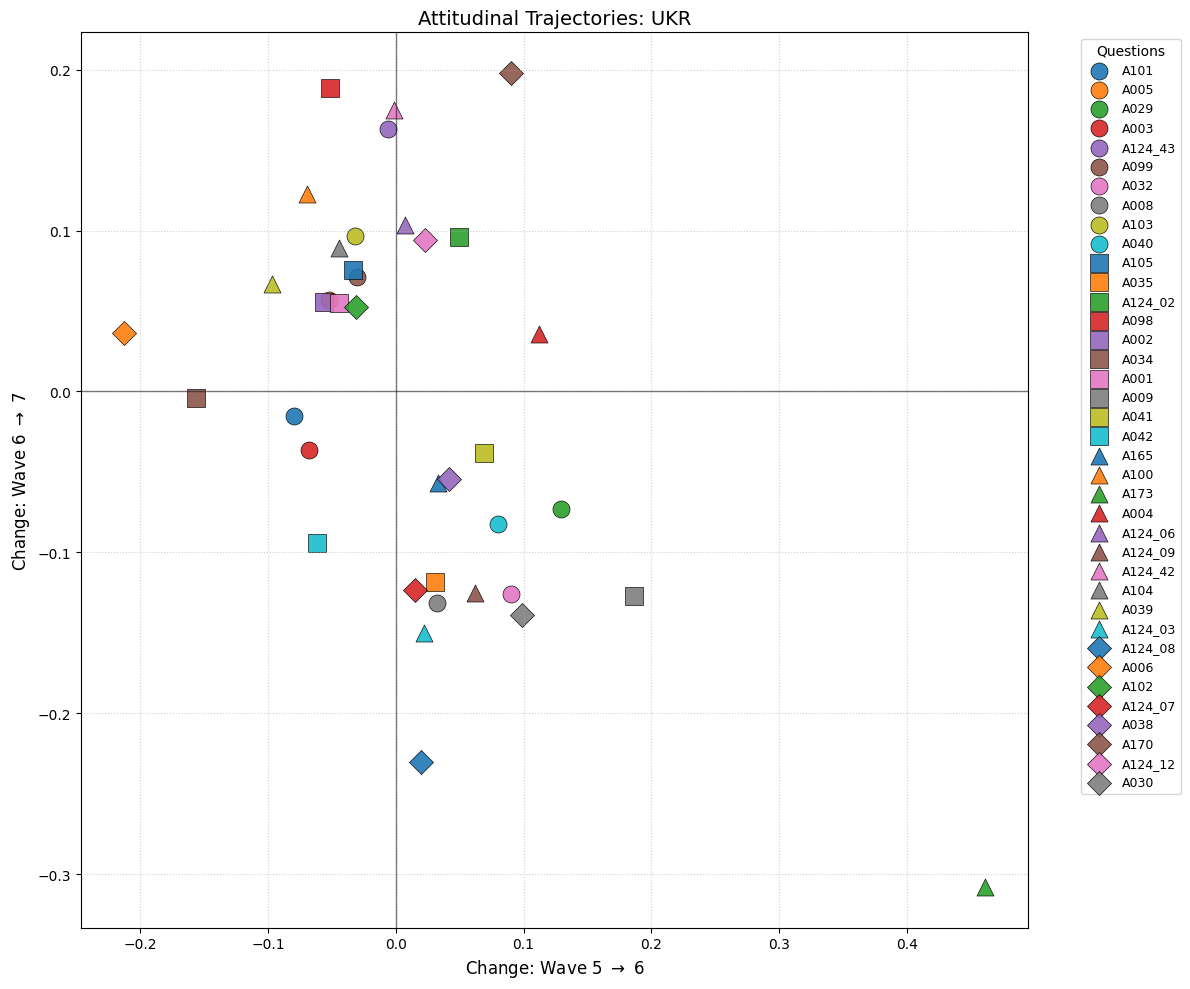

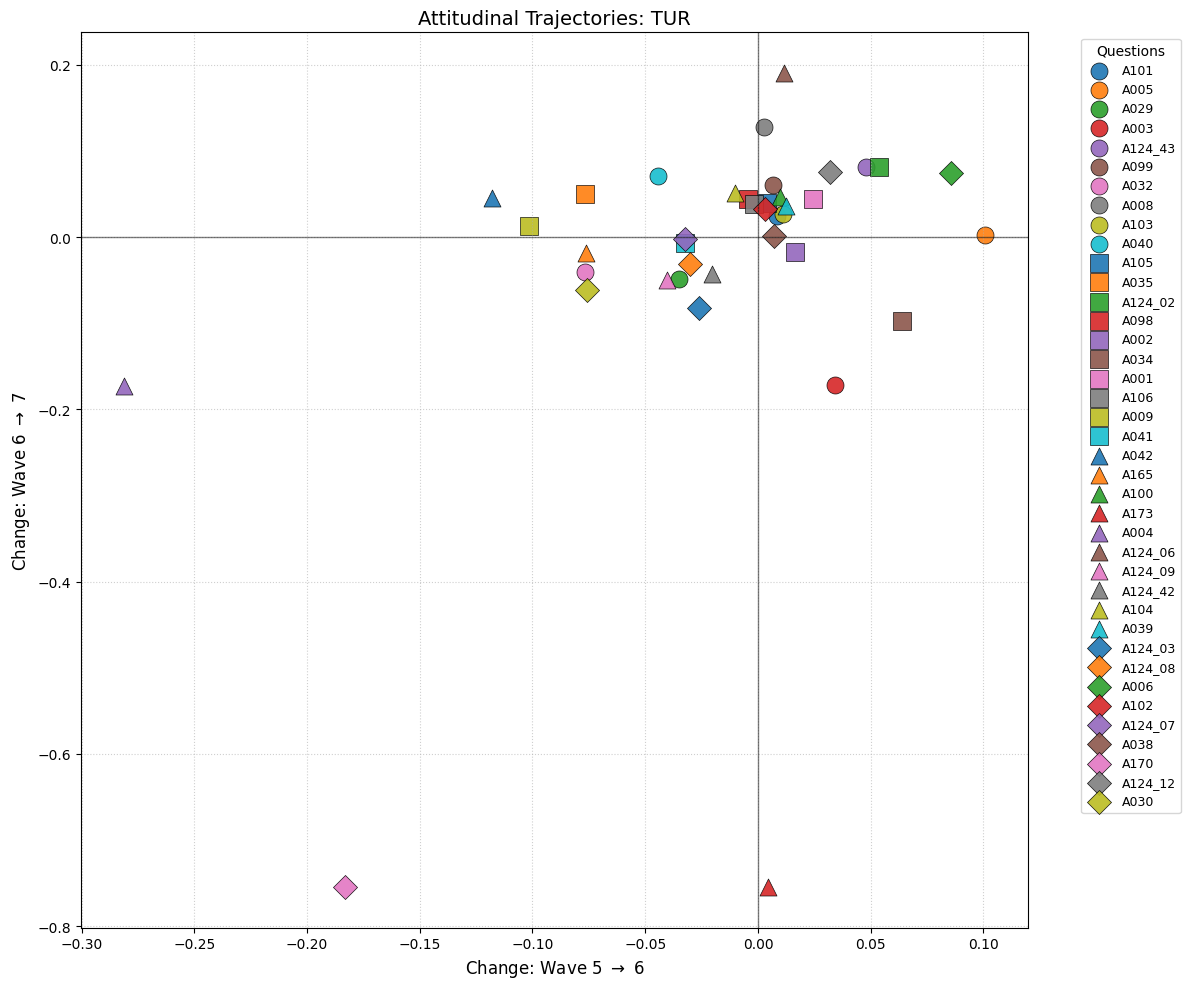

In [7]:
import random
common_countries = set(wave_a_to_b['country']).intersection(set(wave_b_to_c['country']))
country_list = list(common_countries)
random.shuffle(country_list)
selected_countries = country_list[:4]
selected_countries.append('UKR')
selected_countries.append('TUR')
exclude_questions_prefixes = ['E179']

for i, random_country in enumerate(selected_countries):
    import matplotlib.pyplot as plt
    import itertools

    # 1. Define sets of markers and colors to mix and match
    # Matplotlib markers: o=circle, s=square, ^=triangle, D=diamond, p=pentagon, *=star, h=hexagon
    markers = ['o', 's', '^', 'D', 'p', '*', 'h', 'v', '<', '>']
    colors = plt.cm.tab10.colors  # Uses the standard 10-color palette

    # Create a list of unique (color, marker) combinations
    styles = list(itertools.product(markers, colors))

    # 2. Identify common questions
    questions_a_to_b = set(wave_a_to_b[wave_a_to_b['country'] == random_country]['question'])
    questions_b_to_c = set(wave_b_to_c[wave_b_to_c['country'] == random_country]['question'])
    common_questions = list(questions_a_to_b.intersection(questions_b_to_c))

    plt.figure(figsize=(12, 10))

    # 3. Iterate through questions and assign a unique style to each
    for i, question in enumerate(common_questions):
        if any(question.startswith(prefix) for prefix in exclude_questions_prefixes):
            continue
        # Retrieve the specific style for this index
        marker_style = styles[i % len(styles)][0]
        color_style = styles[i % len(styles)][1]
        
        # Calculate Deltas
        row_a_b = wave_a_to_b[(wave_a_to_b['country'] == random_country) & (wave_a_to_b['question'] == question)]
        delta_a_b = row_a_b['mean_wave_' + wave_b].values[0] - row_a_b['mean_wave_' + wave_a].values[0]
        
        row_b_c = wave_b_to_c[(wave_b_to_c['country'] == random_country) & (wave_b_to_c['question'] == question)]
        delta_b_c = row_b_c['mean_wave_' + wave_c].values[0] - row_b_c['mean_wave_' + wave_b].values[0]
        
        # Plot with unique color and marker
        plt.scatter(delta_a_b, delta_b_c, 
                    label=question, 
                    s=150, 
                    marker=marker_style, 
                    color=color_style,
                    alpha=0.9, 
                    edgecolor='black', 
                    linewidth=0.5)

    # 4. Formatting and Quadrant Lines
    plt.axhline(0, color='black', linewidth=1, alpha=0.5)
    plt.axvline(0, color='black', linewidth=1, alpha=0.5)
    plt.xlabel('Change: Wave 5 $\\rightarrow$ 6', fontsize=12)
    plt.ylabel('Change: Wave 6 $\\rightarrow$ 7', fontsize=12)
    plt.title(f'Attitudinal Trajectories: {random_country}', fontsize=14)

    # Place legend outside
    plt.legend(title="Questions", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()